In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from matplotlib.patches import FancyBboxPatch
import gzip
import time
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit
import os
import h5py
from pathlib import Path

In [2]:
###########################################################

file_dir = os.getcwd()

os.chdir(file_dir)

###########################################################

In [3]:
# PARAMETER DEFINITIONS AND LOADING DATA FOR PLOTTING

df = pd.read_csv('../QSim_Data/09-1265A-E_Advantage_system5_4_annealing_schedule.csv', sep=',', decimal='.')
sa = np.array([round(df['s'][i],3) for i in range(1000)])
Ga = np.array([round(df['A(s) (GHz)'][i],3)*np.pi for i in range(1000)])
Ja = np.array([round(df['B(s) (GHz)'][i],3)*np.pi for i in range(1000)])

def sc(E,gc=1.):
    return sa[np.argmin(abs(Ga-gc*E*Ja))]
def Jc(E,gc=1.):
    return E * Ja[np.argmin(abs(Ga-gc*E*Ja))]
def Gc(E,gc=1.):
    return Ga[np.argmin(abs(Ga-gc*E*Ja))]
def Jcp(E,gc=1.):
    return np.gradient(E*Ja,sa)[np.argmin(abs(Ga-gc*E*Ja))]
def Gcp(E,gc=1.):
    return np.gradient(Ga,sa)[np.argmin(abs(Ga-gc*E*Ja))]
def tQ(ta,E,gc=1.):
    # ta must be in ns
    return ta / gc * Jc(E,gc) / (Jcp(E,gc)/Jc(E,gc) - Gcp(E,gc)/Gc(E,gc))
def tQ_to_ta(tq,E,gc=1.):
    # ta must be in ns
    return tq * gc / Jc(E,gc) * (Jcp(E,gc)/Jc(E,gc) - Gcp(E,gc)/Gc(E,gc))
def hcoJc(h,E,gc=1.):
    return h
def hcoJc_to_hz(hcoJc,E,gc=1.):
    return hcoJc
def en_to_lambda(E,gc=1.):
    return ((Jcp(E,gc)/Jc(E,gc) - Gcp(E,gc)/Gc(E,gc)) / Jc(E,gc)) / ((Jcp(1.,gc)/Jc(1.,gc) - Gcp(1.,gc)/Gc(1.,gc)) / Jc(1.,gc))

en_range = np.linspace(.1,2.,20).round(6)
            
ens, ens1, tqs, tas, hcojs, hzs = [], [], [], [], [], []
for en in en_range:
    for tq in np.geomspace(tQ(5,.1),tQ(100,2.),40):
        if tQ(5,en) < tq < tQ(100,en):
            for hz in np.concatenate((np.geomspace(hcoJc(-.1,.1), hcoJc(-.01,.1), 12),
                                      np.geomspace(hcoJc(-1.,.1), hcoJc(-.11,.1), 12))):
                if hcoJc(-1.,en) <= hz <= hcoJc(-0.,en):
                    hcojs.append(hz.round(6))
                    hzs.append(hcoJc_to_hz(hz,en).round(6))
                    ens.append(en.round(6))
                    tqs.append(tq.round(6))
                    tas.append((tQ_to_ta(tq,en)/1000.).round(6))

L = 5564
J = -1.

hzenta_range = [[ens[i],tas[i],hzs[i]] for i in range(len(ens))]

profil = 'jvodebjuelich'
num_reads = 1000
embedding_string_short = '54chainPBC'
auto_scale = False
answer_mode="raw"
fast_anneal=True

#ds = range(0,L//2+1)
ds = range(0,1)

# READ ANALYZED RESULTS

with gzip.open('../QSim_Data/1D_tfim_1st_sweep_mag.txt.gz', "r") as f:
    fvd_mags = eval(f.read())
with gzip.open('../QSim_Data/1D_tfim_1st_sweep_corr.txt.gz', "r") as f:
    fvd_corrs = eval(f.read())

# PLOTTING CONVERSION

tqsu = np.unique(tqs)
hcojcsu = np.unique(hcojs)
datamag = {}
datanex = {}
keys = []
for tq in tqsu:
    for hcojc in hcojcsu:
        datamag[(tq,hcojc)] = []
        datanex[(tq,hcojc)] = []
        keys.append((tq,hcojc))

for hzentaind, [en,ta,hz] in enumerate(hzenta_range):

    try:
        tq = tqsu[np.abs(tQ(1000*ta,en).round(6) - tqsu).argmin()]
        hcojc = hcojcsu[np.abs(hcoJc(hz,en) - hcojcsu).argmin()]
        datamag[(tq,hcojc)].append([en_to_lambda(en),fvd_mags[(L,J,hz,ta,en,num_reads,'szmean')]])
        datanex[(tq,hcojc)].append([en_to_lambda(en),fvd_mags[(L,J,hz,ta,en,num_reads,'nexmean')]])
    except:
        continue

for key in keys:
    if datamag[key] == []:
        del datamag[key]
        del datanex[key]
        print(key)

# PLOTTING CONVERSION

mag = {}
nex = {}
corr = {}

for hzentaind, [en,ta,hz] in enumerate(hzenta_range):
    try:
        mag[(hz,ta,en)] = fvd_mags[(L,J,hz,ta,en,num_reads,'szmean')]
        nex[(hz,ta,en)] = fvd_mags[(L,J,hz,ta,en,num_reads,'nexmean')]

        for d in ds:
            corr[(hz,ta,en,d)] = fvd_corrs[(L,J,hz,ta,en,num_reads,d,'szsz'+str(d)+'mean')]
    except:
        continue

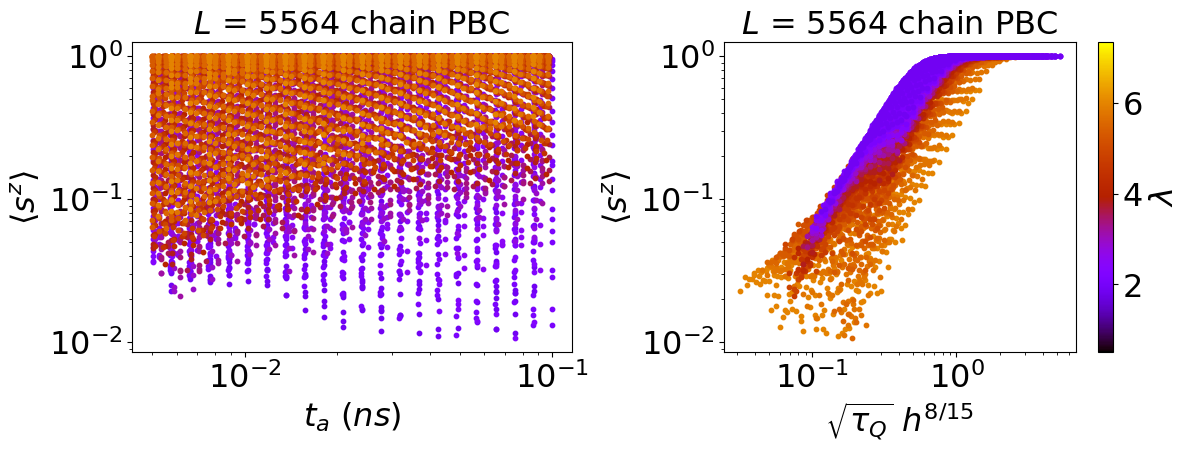

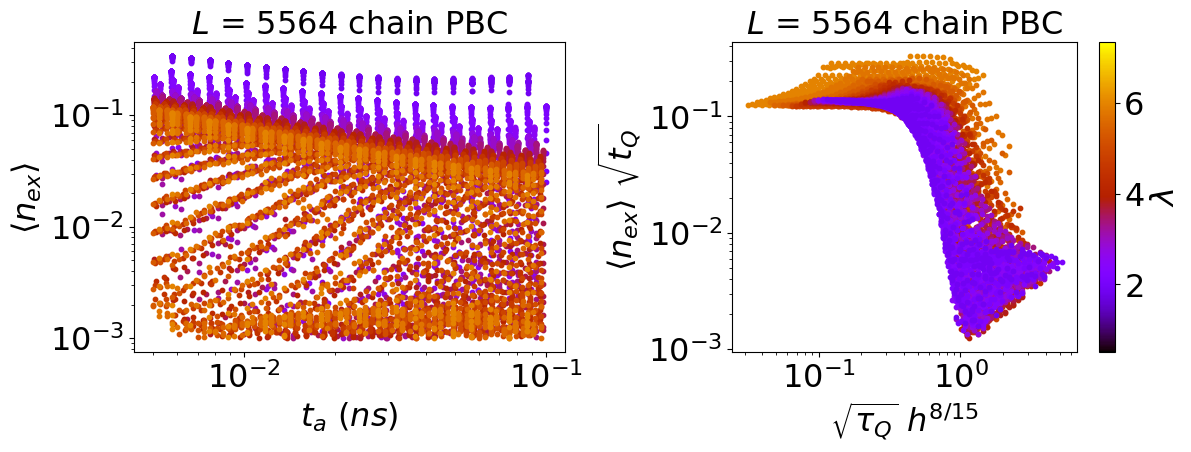

In [4]:
# PLOT RESULTS

lambdas = np.array([en_to_lambda(e) for e in en_range])
third_axis = np.flip(np.unique(lambdas))
third_axis_name = r'$\lambda$'

cmap = plt.get_cmap('gnuplot')
colors = np.array([cmap(i) for i in np.linspace(.2, .8, len(third_axis))])

lw = .5
s = 10

xnex, ynex, xsz, ysz = np.array([]), np.array([]), np.array([]), np.array([])
xmean = .15
    
figsz, axsz = plt.subplots(1,2,figsize=(12,5))
axsz[0].set_xlabel("$t_a$ ($ns$)", fontsize = 23)
axsz[0].tick_params(axis='x',labelsize=23)
axsz[0].tick_params(axis='y',labelsize=23)
axsz[0].set_ylabel(r"$\langle s^z\rangle$", fontsize=23)
axsz[0].set_title('$L$ = '+str(L)+' chain PBC', fontsize = 23)
axsz[1].set_xlabel(r"$\sqrt{\tau_Q}$ $h^{8/15}$", fontsize = 23)
axsz[1].tick_params(axis='x',labelsize=23)
axsz[1].tick_params(axis='y',labelsize=23)
axsz[1].set_ylabel(r"$\langle s^z\rangle$", fontsize=23)
axsz[1].set_title('$L$ = '+str(L)+' chain PBC', fontsize = 23)

fignex, axnex = plt.subplots(1,2,figsize=(12,5))
axnex[0].set_xlabel("$t_a$ ($ns$)", fontsize = 23)
axnex[0].tick_params(axis='x',labelsize=23)
axnex[0].tick_params(axis='y',labelsize=23)
axnex[0].set_ylabel(r"$\langle n_{ex}\rangle$", fontsize=23)
axnex[0].set_title('$L$ = '+str(L)+' chain PBC', fontsize = 23)
axnex[1].set_xlabel(r"$\sqrt{\tau_Q}$ $h^{8/15}$", fontsize = 23)
axnex[1].tick_params(axis='x',labelsize=23)
axnex[1].tick_params(axis='y',labelsize=23)
axnex[1].set_ylabel(r"$\langle n_{ex}\rangle$ $\sqrt{t_Q}$", fontsize=23)
axnex[1].set_title('$L$ = '+str(L)+' chain PBC', fontsize = 23)

for taxind, tax in enumerate(en_range):
    for hzind, hz in enumerate(np.unique(hzs)):
        
        tas1 = np.unique(np.array(tas))
        tqs = np.array([tQ(ta*1000,tax) for ta in tas1])
        mag1 = np.full(len(tas1),-2.)
        nex1 = np.full(len(tas1),-2.)
        for taind, ta in enumerate(tas1):
            try:
                if mag[(hz,ta,tax)] > 10**-2:
                    mag1[taind] = mag[(hz,ta,tax)]
                else:
                    mag1[taind] = np.nan
                if nex[(hz,ta,tax)] > 10**-3:
                    nex1[taind] = nex[(hz,ta,tax)]
                else:
                    nex1[taind] = np.nan
            except:
                mag1[taind] = np.nan
                nex1[taind] = np.nan

        axsz[0].scatter(tas1,mag1, color=colors[taxind], s=s)
        axsz[0].plot(tas1,mag1, color=colors[taxind], lw=lw)
        axsz[1].scatter(np.sqrt(tqs)*abs(hz)**(8/15), mag1, color=colors[len(en_range)-1-taxind], s=s)
        #axsz[1].plot(np.sqrt(tqs)*abs(en*tax/Jc(en))**(8/15),mag[taxind,:,enind], color=colors[taxind], lw=lw)
        axnex[0].scatter(tas1,nex1, color=colors[taxind], s=s)
        axnex[0].plot(tas1,nex1, color=colors[taxind], lw=lw)
        axnex[1].scatter(np.sqrt(tqs)*abs(hz)**(8/15),np.sqrt(tqs)*nex1, color=colors[len(en_range)-1-taxind], s=s)
        #axnex[1].plot(np.sqrt(tqs)*abs(en*tax/Jc(en))**(8/15),np.sqrt(tqs)*nex[taxind,:,enind], color=colors[taxind], lw=lw)
        
        xtemp = np.sqrt(tqs)*abs(hz)**(8/15)
        ynextemp = np.sqrt(tqs)*nex1
        ysztemp = mag1
        for indtemp, temp in enumerate(ynextemp):
            if temp > 0:
                xnex = np.concatenate((xnex,np.array([xtemp[indtemp]])))
                ynex = np.concatenate((ynex,np.array([temp])))
                
        for indtemp, temp in enumerate(xtemp):
            if temp <= xmean and ysztemp[indtemp] > 0:
                xsz = np.concatenate((xsz,np.array([xtemp[indtemp]])))
                ysz = np.concatenate((ysz,np.array([ysztemp[indtemp]])))
        
figsz.tight_layout(pad=2.5)
fignex.tight_layout(pad=2.5)
normalize = mcolors.Normalize(vmin=max(abs(third_axis)), vmax=min(abs(third_axis)))
scalarmappaple = cm.ScalarMappable(norm=normalize, cmap=cmap)
scalarmappaple.set_array(third_axis)
cbar = plt.colorbar(scalarmappaple, ax=axsz[1])
cbar.set_label(label=third_axis_name, size='23')
cbar.ax.tick_params(labelsize='23')
cbar = plt.colorbar(scalarmappaple, ax=axnex[1])
cbar.set_label(label=third_axis_name, size='23')
cbar.ax.tick_params(labelsize='23')
axsz[0].set_xscale('log')
axsz[0].set_yscale('log')
axsz[1].set_xscale('log')
axsz[1].set_yscale('log')
axnex[0].set_xscale('log')
axnex[0].set_yscale('log')
axnex[1].set_xscale('log')
axnex[1].set_yscale('log')

/tmp/ipykernel_35898/2813131976.py:38: OptimizeWarning: Covariance of the parameters could not be estimated
  params = curve_fit(fit_func, x, y)
/tmp/ipykernel_35898/2813131976.py:49: OptimizeWarning: Covariance of the parameters could not be estimated
  params = curve_fit(fit_func, x, y)
/tmp/ipykernel_35898/2813131976.py:19: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(1,2,figsize=(12,5))


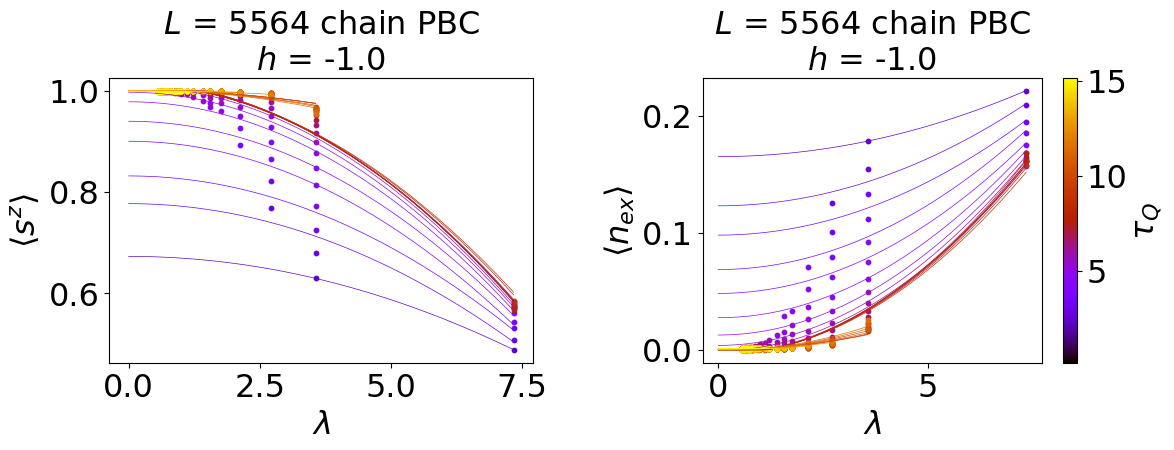

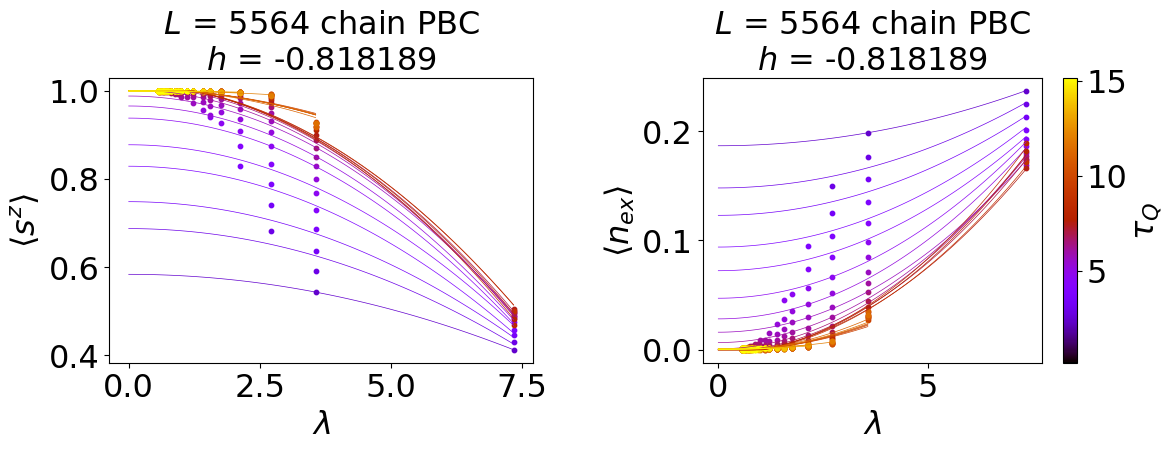

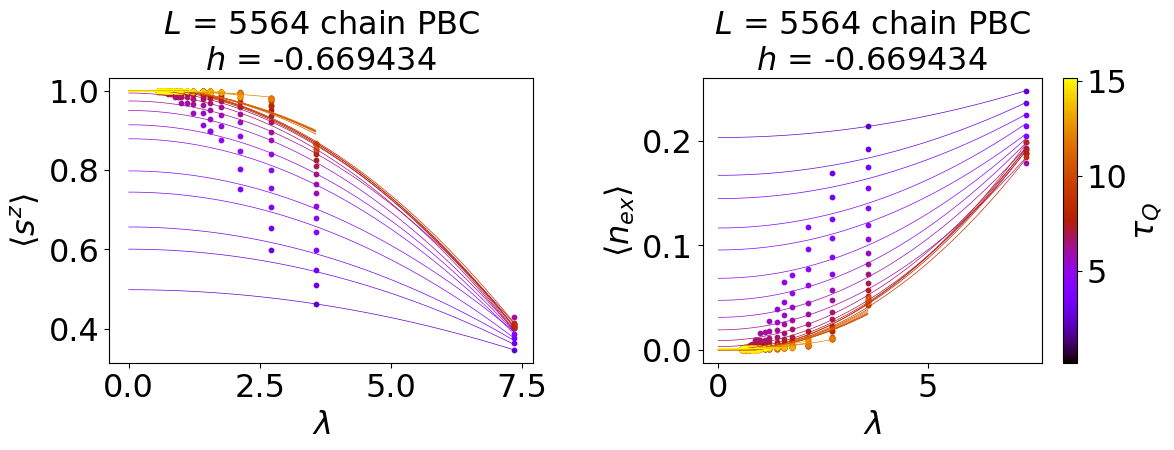

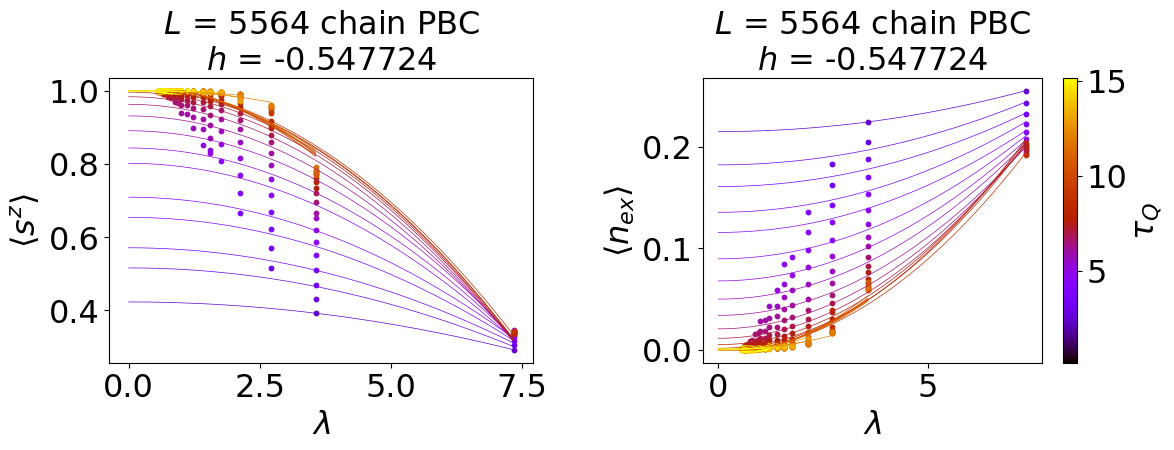

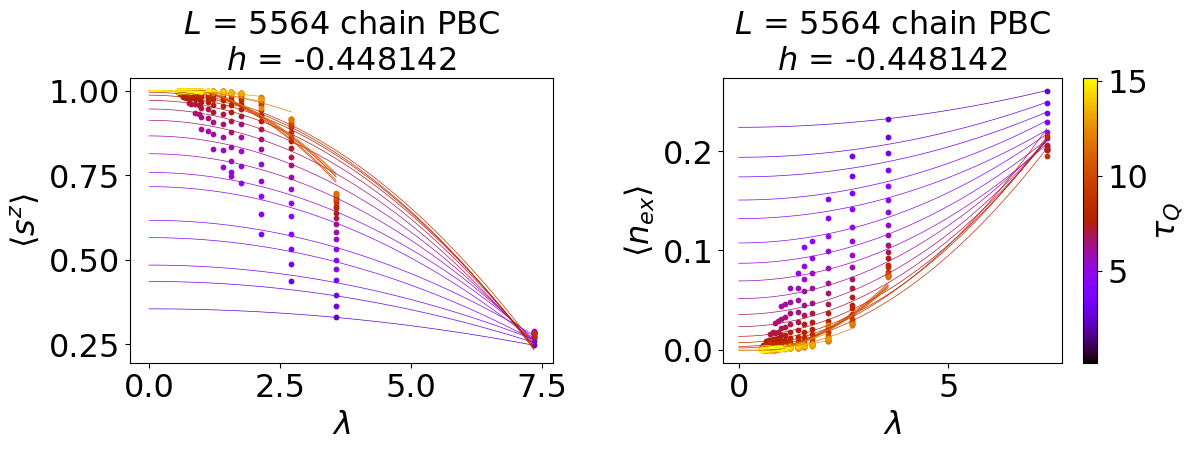

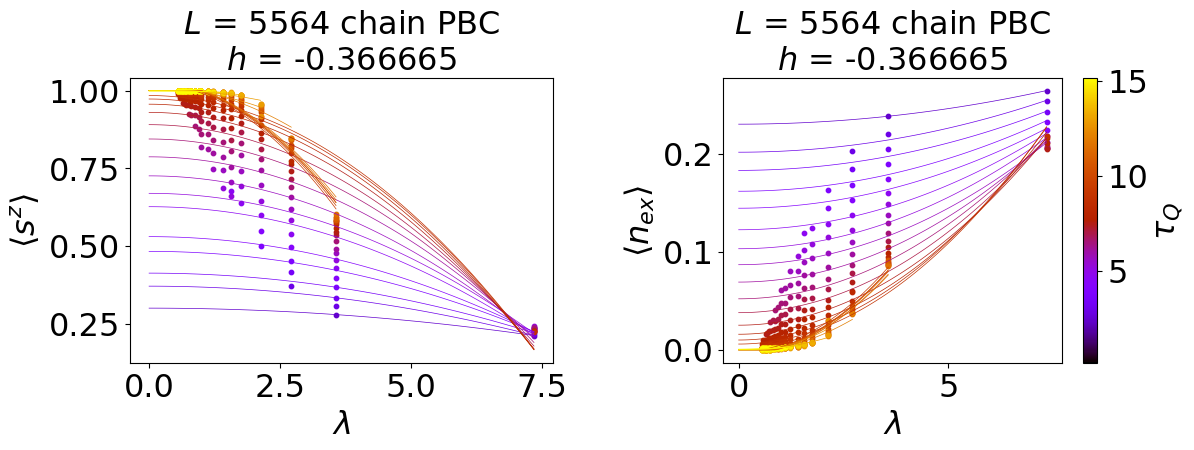

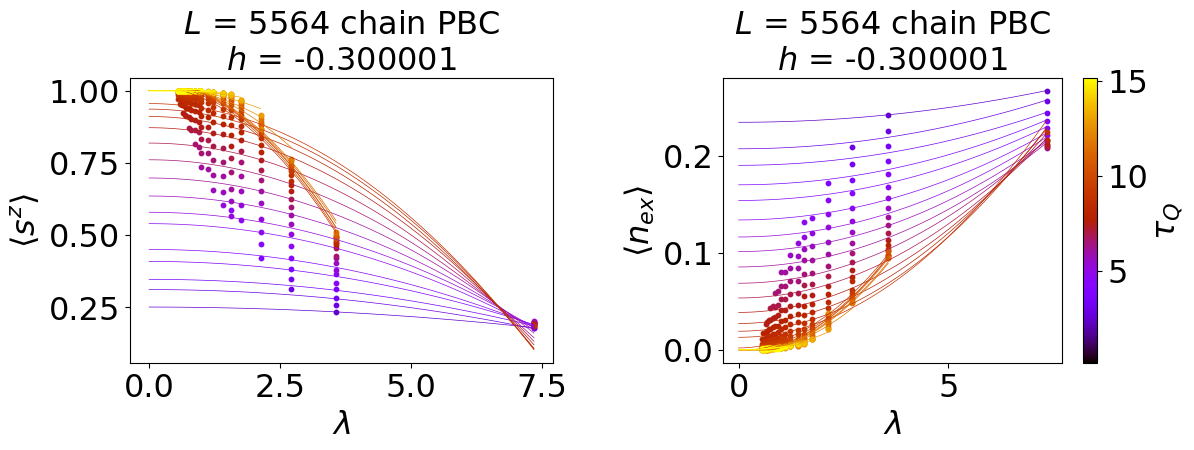

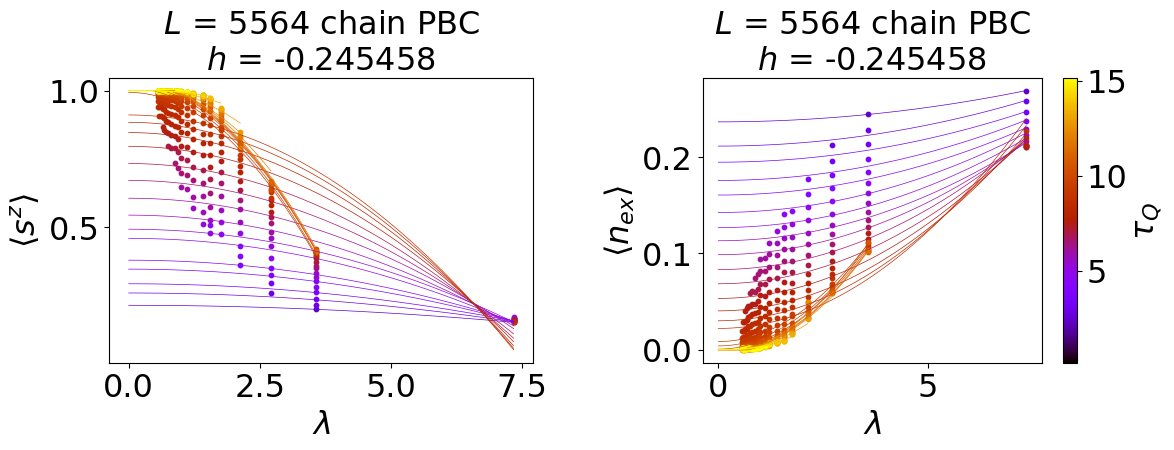

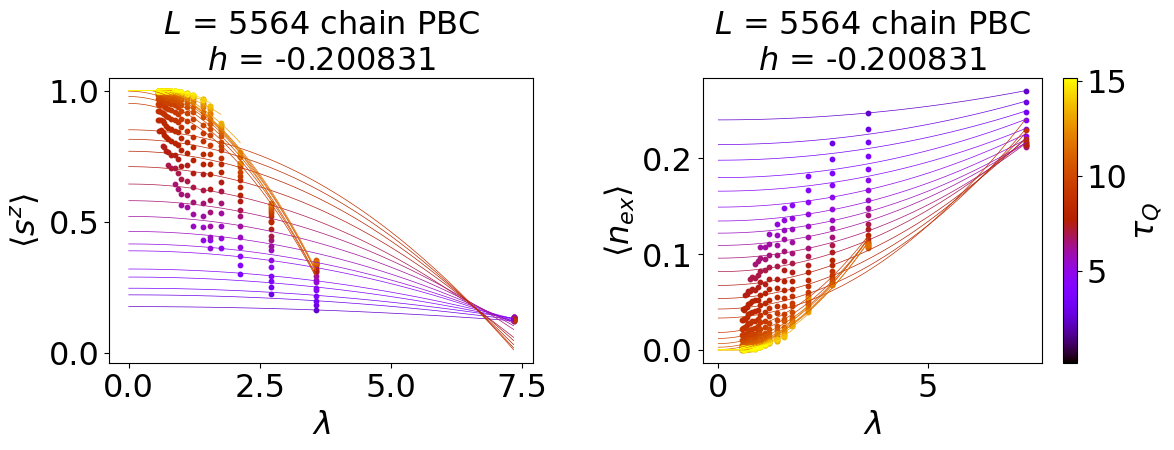

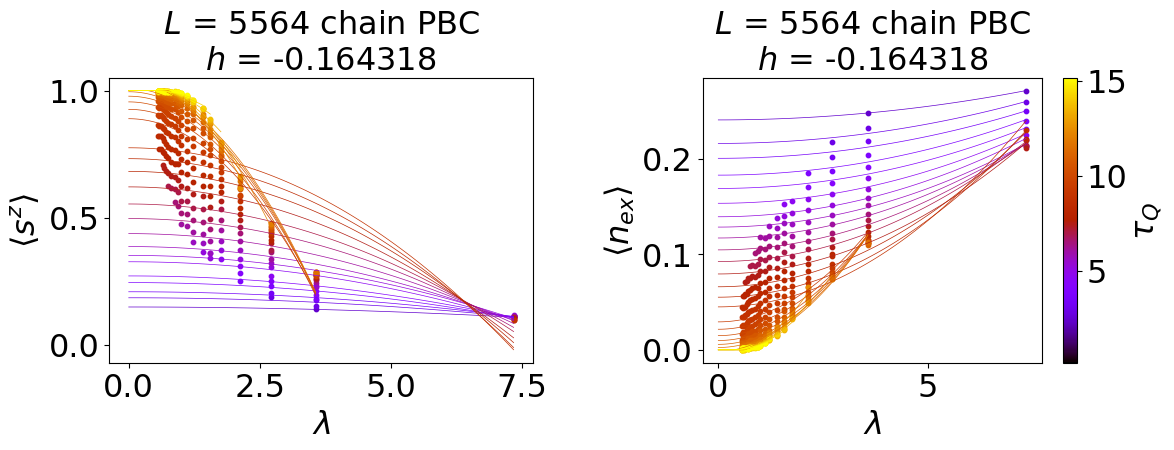

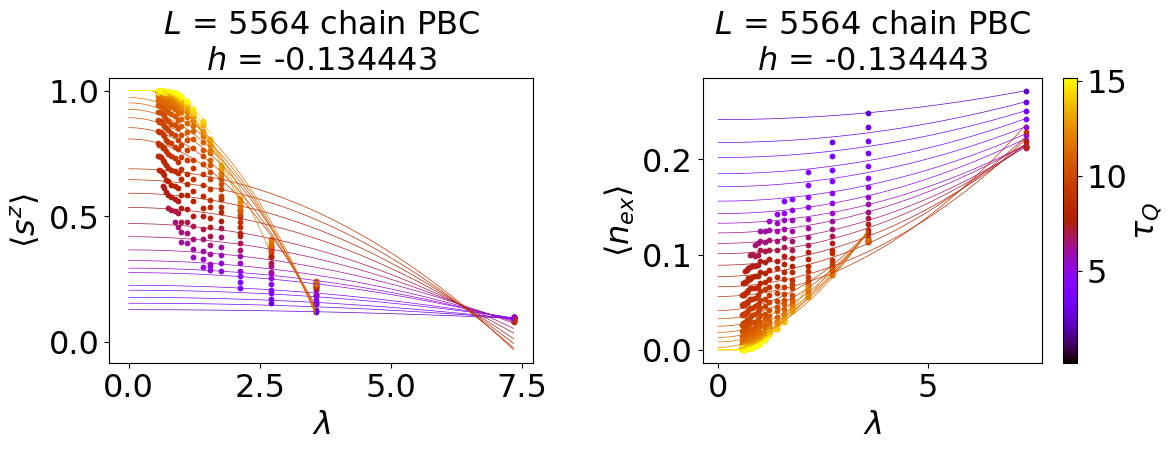

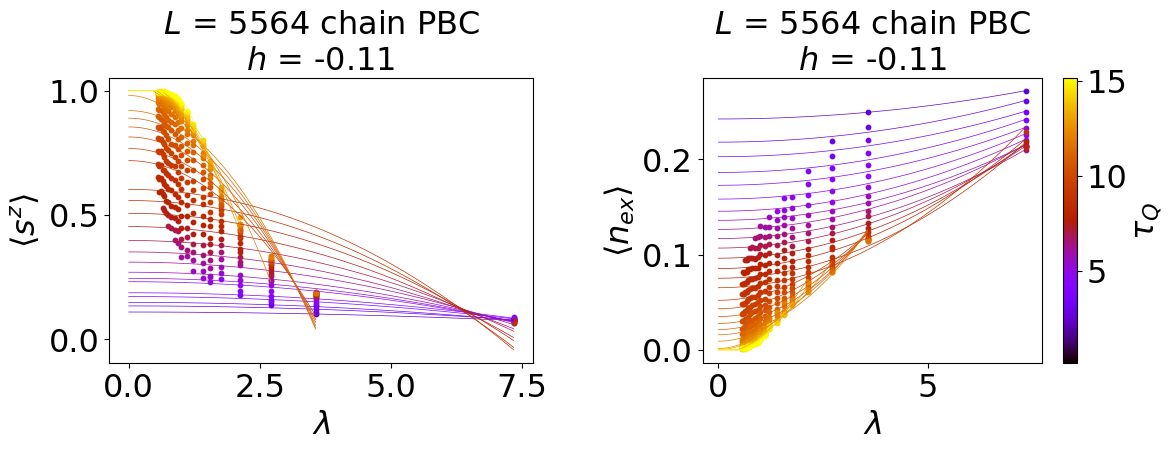

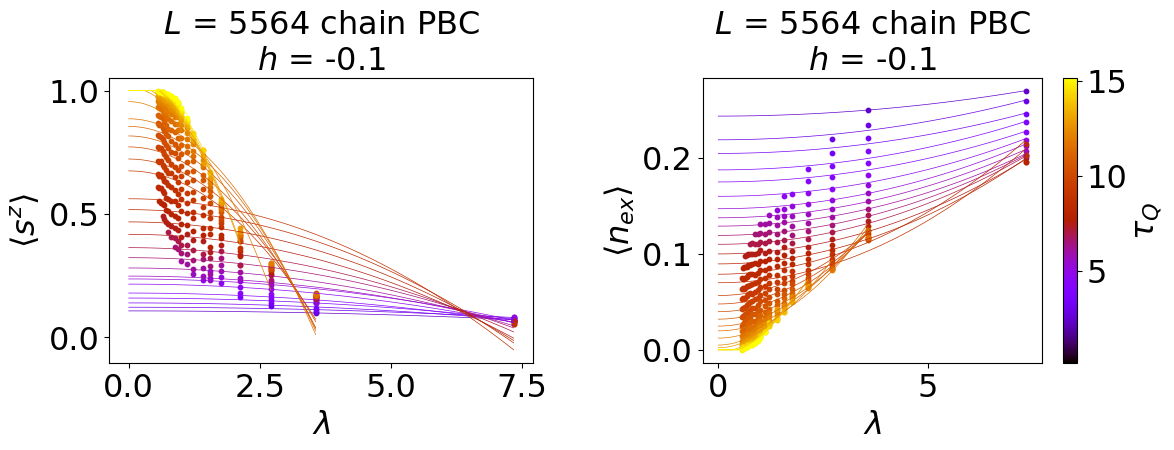

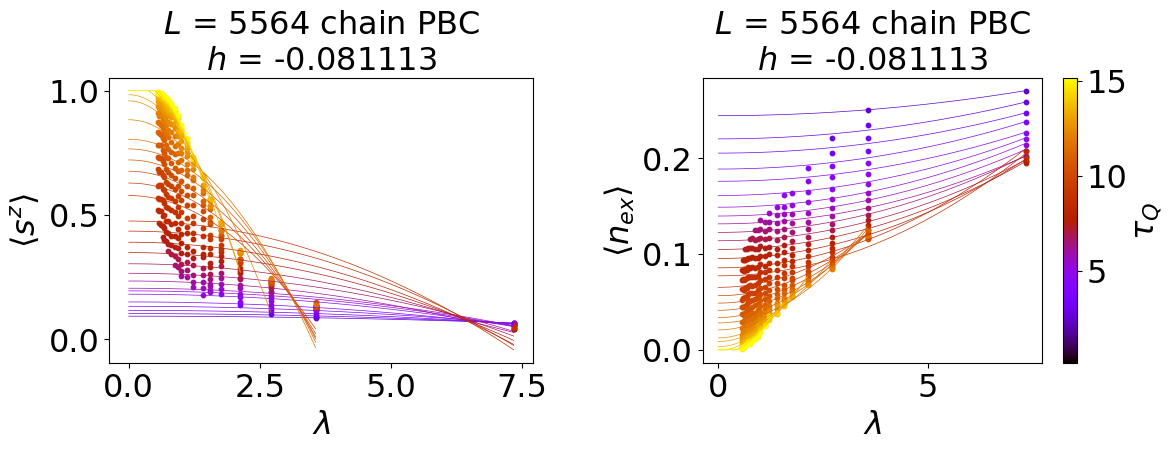

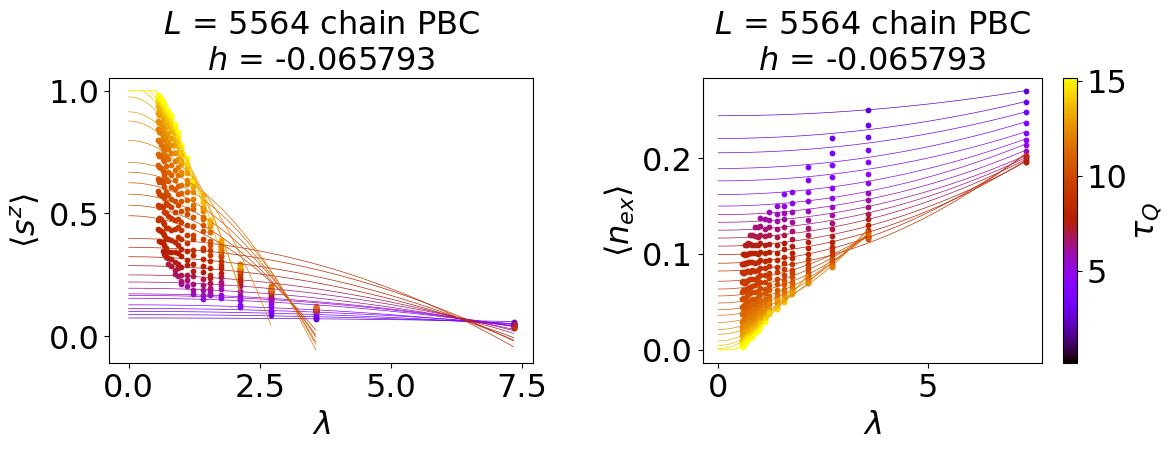

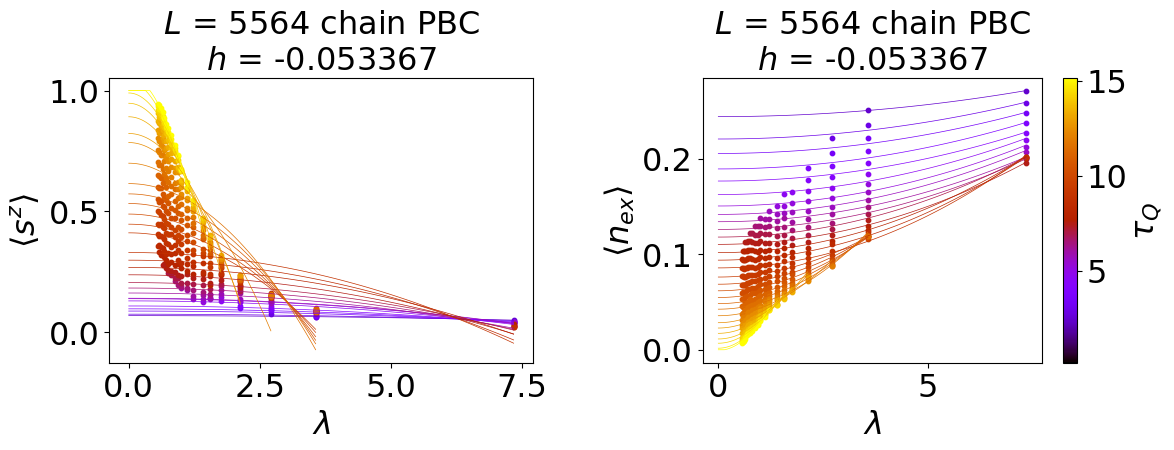

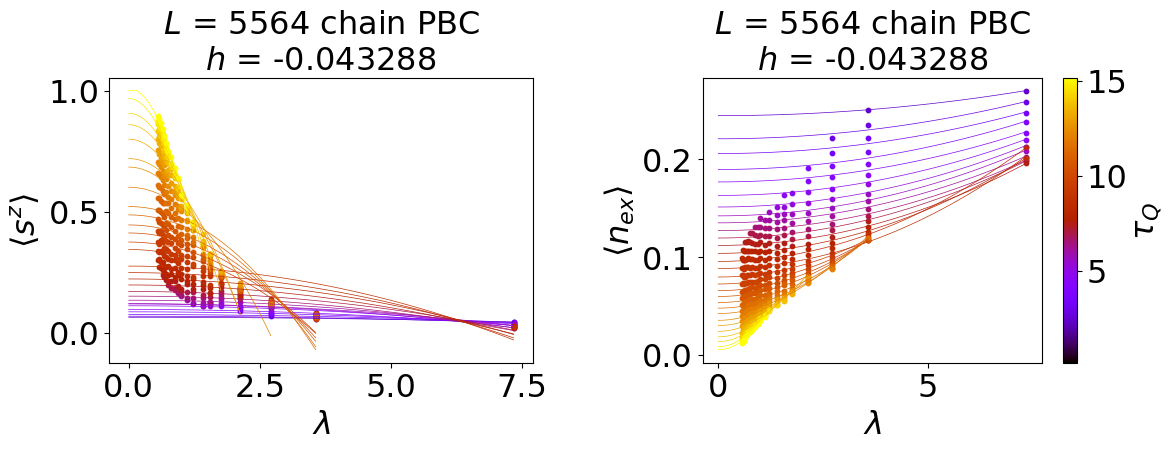

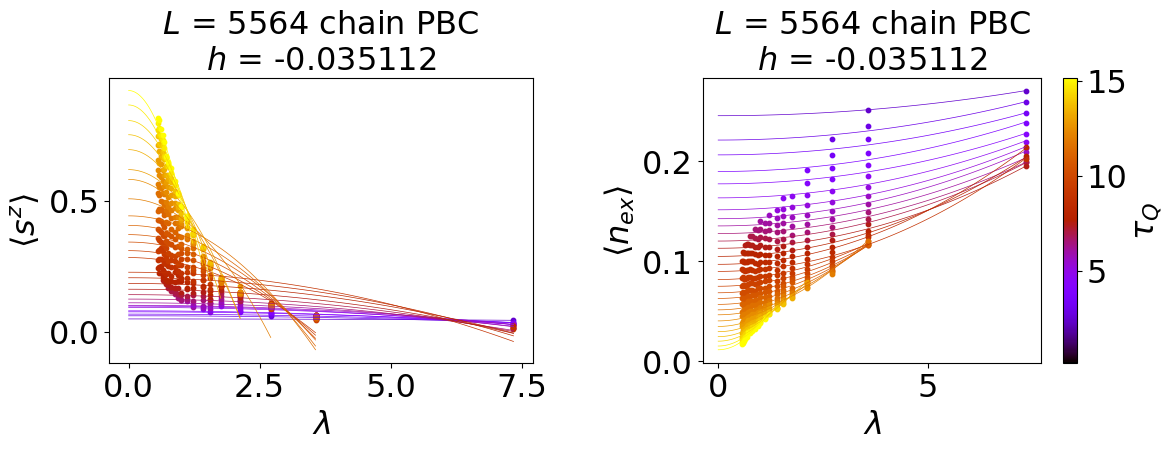

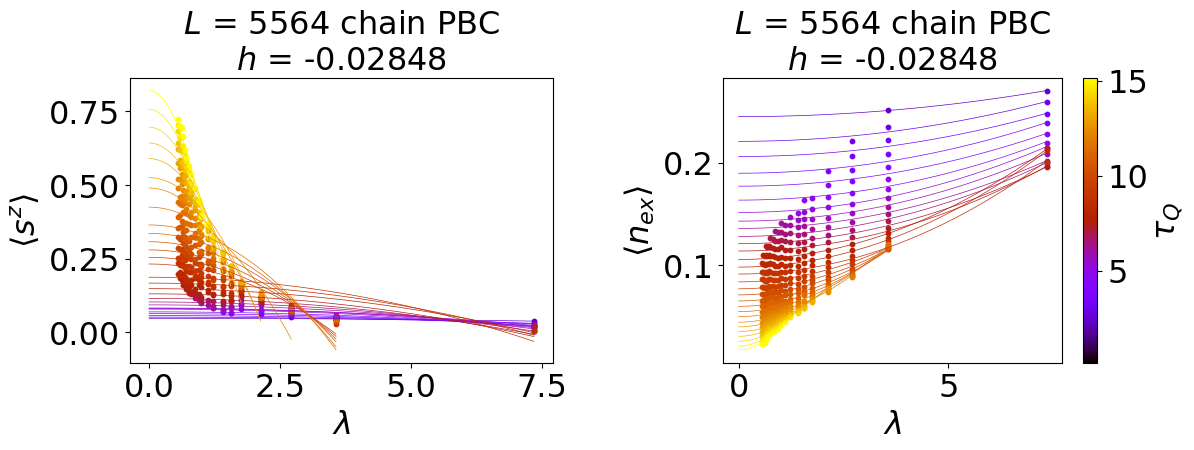

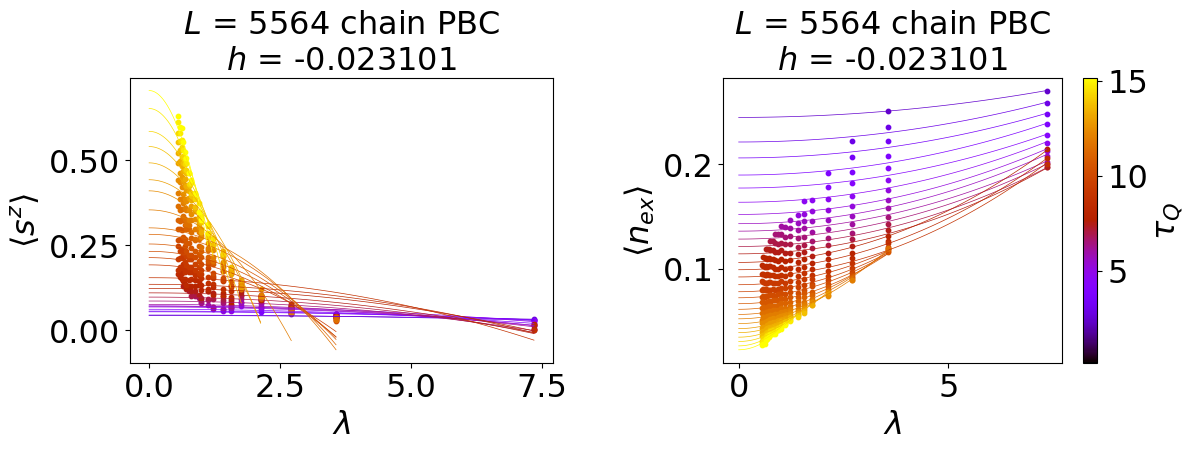

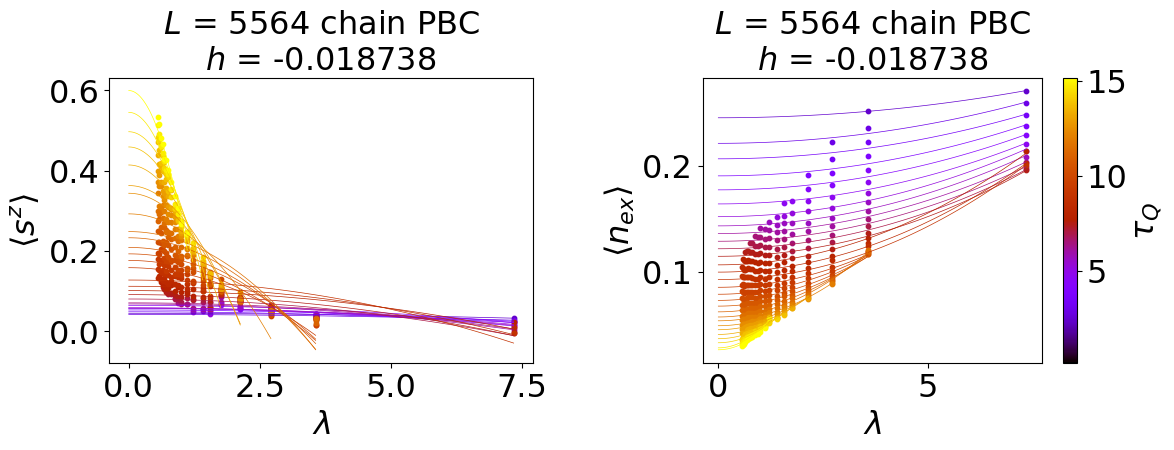

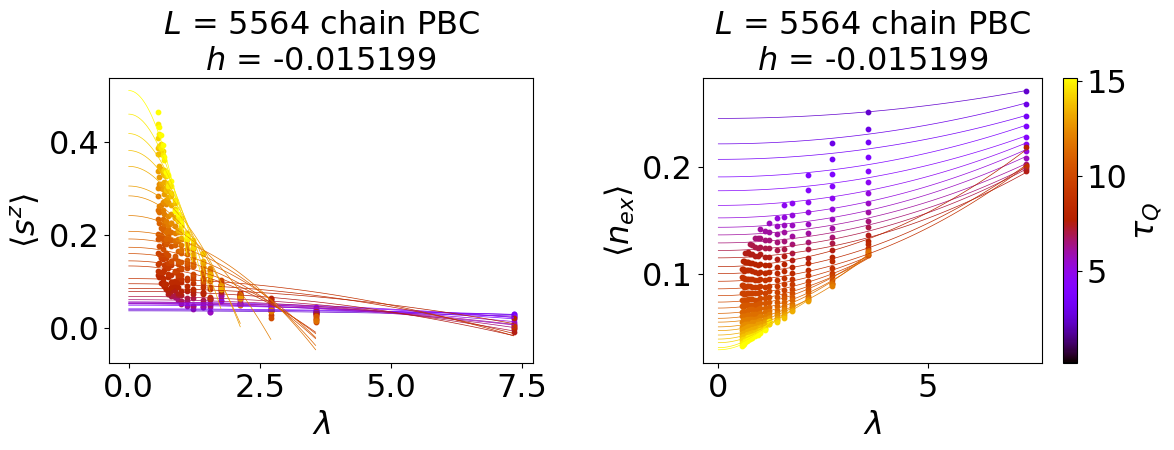

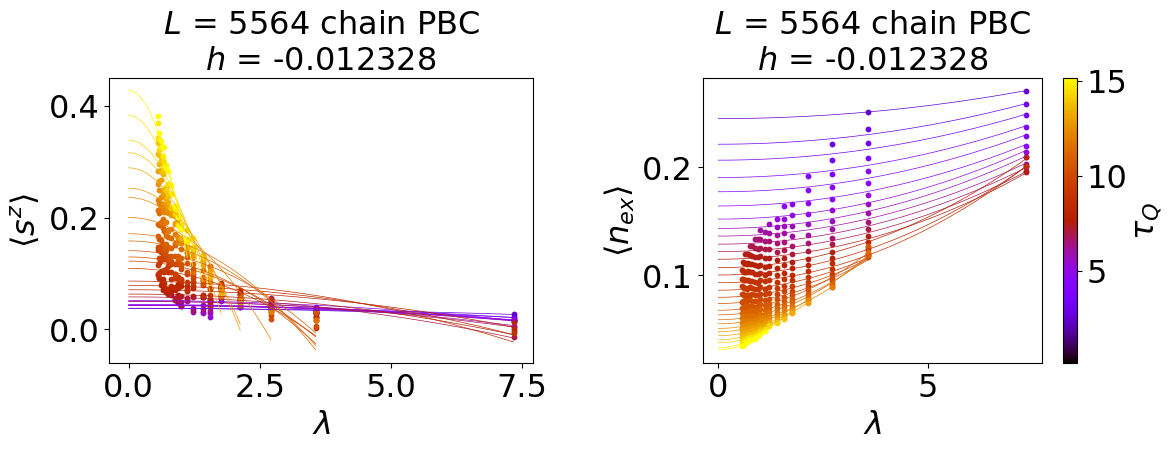

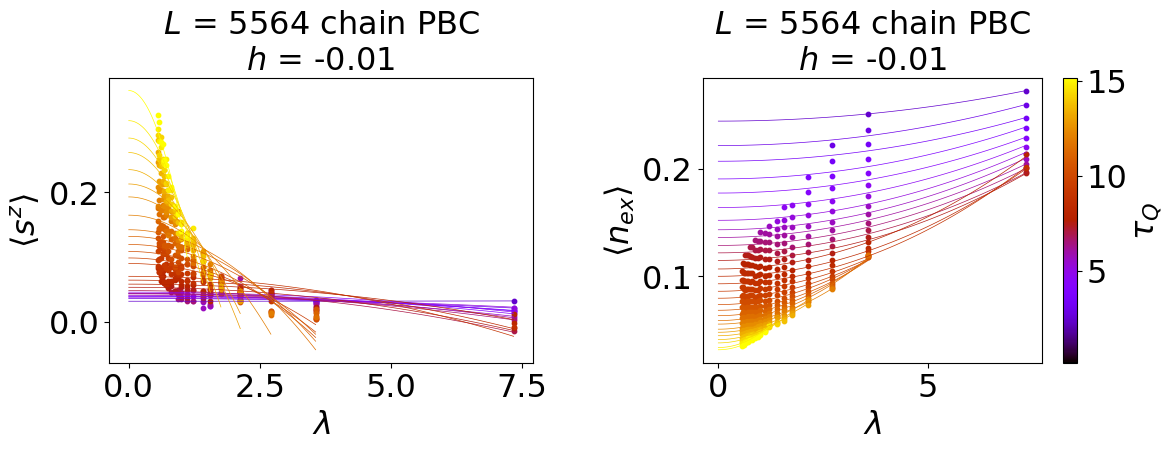

In [5]:
# PLOT RESULTS

def fit_func(x, C0, C2):
    return C0 + C2*x**2

third_axis = tqsu[:34]
third_axis_name = r'$\tau_Q$'
cmap = plt.get_cmap('gnuplot')
colors = [cmap(i) for i in np.linspace(0., 1., len(third_axis))]

lw = .5
s = 10

znemag = np.full((len(hcojcsu),len(third_axis)),-2.)
znenex = np.full((len(hcojcsu),len(third_axis)),-2.)

for hcojcind, hcojc in enumerate(hcojcsu):
    
    fig, ax = plt.subplots(1,2,figsize=(12,5))
    
    ax[0].set_xlabel(r"$\lambda$", fontsize = 23)
    ax[0].tick_params(axis='x',labelsize=23)
    ax[0].tick_params(axis='y',labelsize=23)
    ax[0].set_ylabel(r"$\langle s^z\rangle$", fontsize=23)
    ax[0].set_title('$L$ = '+str(L)+' chain PBC\n$h$ = '+str(hcojc), fontsize = 23)

    ax[1].set_xlabel(r"$\lambda$", fontsize = 23)
    ax[1].tick_params(axis='x',labelsize=23)
    ax[1].tick_params(axis='y',labelsize=23)
    ax[1].set_ylabel(r"$\langle n_{ex}\rangle$", fontsize=23)
    ax[1].set_title('$L$ = '+str(L)+' chain PBC\n$h$ = '+str(hcojc), fontsize = 23)
    
    for tqi, tq in enumerate(third_axis):
        
        try:
            x = np.array(datamag[(tq,hcojc)])[:,0]
            y = np.array(datamag[(tq,hcojc)])[:,1]
            params = curve_fit(fit_func, x, y)
            [C0, C2] = params[0]
            ax[0].scatter(x, y, color=colors[tqi], s=s)
            x = np.linspace(0.,x[0],100)
            y = [min([fit_func(xi, C0, C2),1.]) for xi in x]
            ax[0].plot(x, y, color=colors[tqi], lw=lw)
            
            znemag[hcojcind,tqi] = min([fit_func(0., C0, C2),1.])

            x = np.array(datanex[(tq,hcojc)])[:,0]
            y = np.array(datanex[(tq,hcojc)])[:,1]
            params = curve_fit(fit_func, x, y)
            [C0, C2] = params[0]
            ax[1].scatter(x, y, color=colors[tqi], s=s)
            x = np.linspace(0.,x[0],100)
            y = [max([fit_func(xi, C0, C2),0.]) for xi in x]
            ax[1].plot(x, y, color=colors[tqi], lw=lw)
            
            znenex[hcojcind,tqi] = fit_func(0., C0, C2)
        except:
            znemag[hcojcind,tqi] = np.nan
            znenex[hcojcind,tqi] = np.nan

    fig.tight_layout(pad=2.5)
    normalize = mcolors.Normalize(vmin=min(abs(third_axis)), vmax=max(abs(third_axis)))
    scalarmappaple = cm.ScalarMappable(norm=normalize, cmap=cmap)
    scalarmappaple.set_array(third_axis)
    cbar = plt.colorbar(scalarmappaple, ax=ax[1])
    cbar.set_label(label=third_axis_name, size='23')
    cbar.ax.tick_params(labelsize='23')
    #axsz.set_xscale('log')
    #axsz.set_yscale('log')
    #axnex.set_xscale('log')
    #axnex.set_yscale('log')

    # fig.savefig('1D_ZNE_extrapolation_hz_'+str(hcojc)+'.pdf')

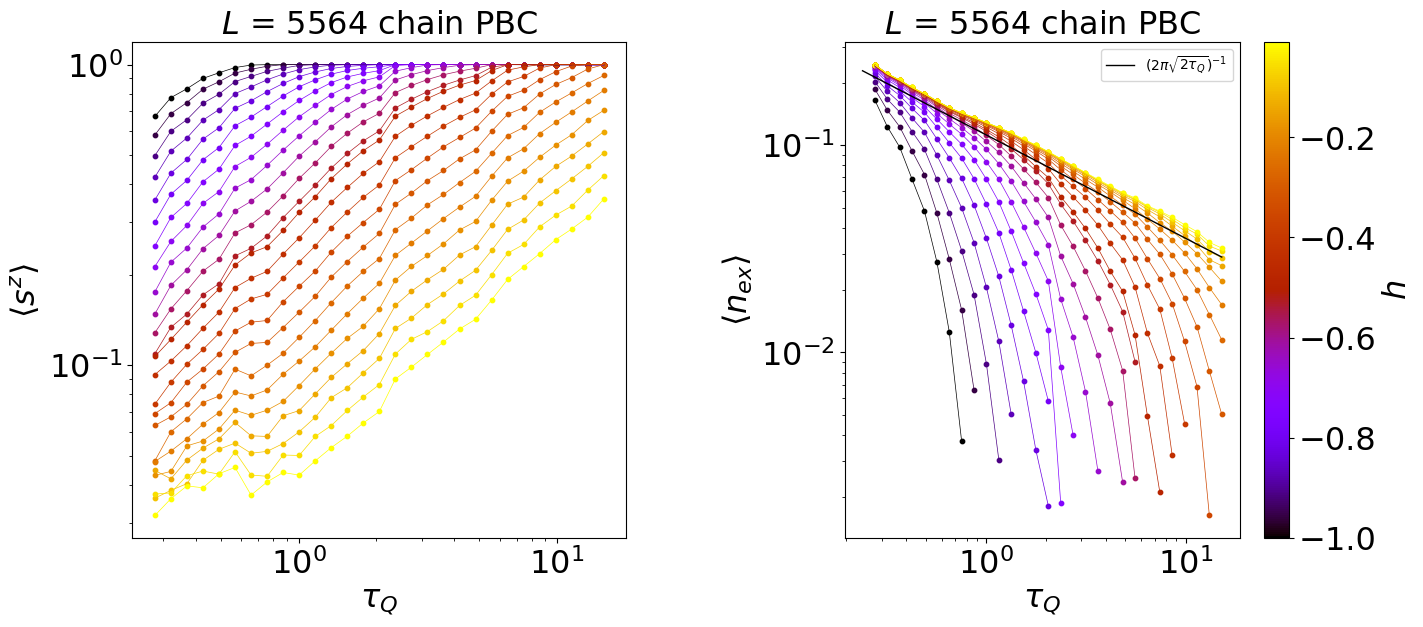

In [6]:
# PLOT RESULTS

third_axis = hcojcsu
third_axis_name = '$h$'
tqs = tqsu[:34]

cmap = plt.get_cmap('gnuplot')
colors = [cmap(i) for i in np.linspace(.0, 1., len(third_axis))]

lw = .5
s = 10
    
fig, ax = plt.subplots(1,2,figsize=(15,8))

ax[0].set_xlabel(r"$\tau_Q$", fontsize = 23)
ax[0].tick_params(axis='x',labelsize=23)
ax[0].tick_params(axis='y',labelsize=23)
ax[0].set_ylabel(r"$\langle s^z\rangle$", fontsize=23)
ax[0].set_title('$L$ = '+str(L)+' chain PBC', fontsize = 23)

ax[1].set_xlabel(r"$\tau_Q$", fontsize = 23)
ax[1].tick_params(axis='x',labelsize=23)
ax[1].tick_params(axis='y',labelsize=23)
ax[1].set_ylabel(r"$\langle n_{ex}\rangle$", fontsize=23)
ax[1].set_title('$L$ = '+str(L)+' chain PBC', fontsize = 23)

for taxind, tax in enumerate(third_axis):

    mask = [znenex[taxind,:] > 1.5*10**-3]
    ax[0].scatter(tqs,znemag[taxind,:], color=colors[taxind], s=s)
    ax[0].plot(tqs,znemag[taxind,:], color=colors[taxind], lw=lw)
    ax[1].scatter(tqs[mask[0]],znenex[taxind,mask[0]], color=colors[taxind], s=s)
    ax[1].plot(tqs[mask[0]],znenex[taxind,mask[0]], color=colors[taxind], lw=lw)

x = np.geomspace(tqs[4],tqs[-1],100)
y = 1/(2*np.pi*np.sqrt(2*x))
ax[1].plot(x, y, color='black', lw=2*lw, label=r'$(2\pi\sqrt{2\tau_Q})^{-1}$')
ax[1].legend()

fig.tight_layout(pad=7)
normalize = mcolors.Normalize(vmin=min(third_axis), vmax=max(third_axis))
scalarmappaple = cm.ScalarMappable(norm=normalize, cmap=cmap)
scalarmappaple.set_array(third_axis)
cbar = plt.colorbar(scalarmappaple, ax=ax[1])
cbar.set_label(label=third_axis_name, size='23')
cbar.ax.tick_params(labelsize='23')
ax[0].set_xscale('log')
ax[0].set_yscale('log')
ax[1].set_xscale('log')
ax[1].set_yscale('log')

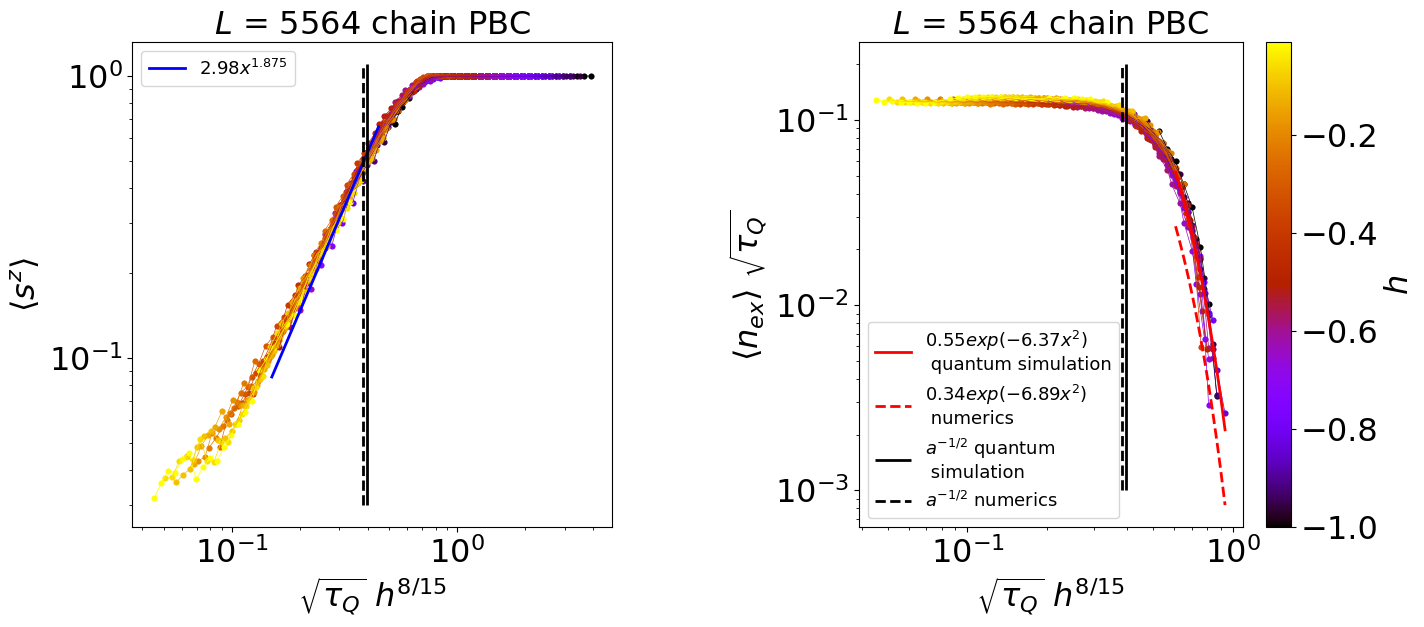

In [7]:
# PLOT RESULTS

third_axis = hcojcsu
third_axis_name = '$h$'
tqs = tqsu[:34]

cmap = plt.get_cmap('gnuplot')
colors = [cmap(i) for i in np.linspace(.0, 1., len(third_axis))]

lw = .5
s = 10
    
fig, ax = plt.subplots(1,2,figsize=(15,8))

ax[0].set_xlabel(r"$\sqrt{\tau_Q}$ $h^{8/15}$", fontsize = 23)
ax[0].tick_params(axis='x',labelsize=23)
ax[0].tick_params(axis='y',labelsize=23)
ax[0].set_ylabel(r"$\langle s^z\rangle$", fontsize=23)
ax[0].set_title('$L$ = '+str(L)+' chain PBC', fontsize = 23)

ax[1].set_xlabel(r"$\sqrt{\tau_Q}$ $h^{8/15}$", fontsize = 23)
ax[1].tick_params(axis='x',labelsize=23)
ax[1].tick_params(axis='y',labelsize=23)
ax[1].set_ylabel(r"$\langle n_{ex}\rangle$ $\sqrt{\tau_Q}$", fontsize=23)
ax[1].set_title('$L$ = '+str(L)+' chain PBC', fontsize = 23)

xszstart, xszend, xnexstart, xnexend = .15, .45, .6, 1.
xnex, ynex, xsz, ysz = np.array([]), np.array([]), np.array([]), np.array([])

for taxind, tax in enumerate(third_axis):

    mask = [znenex[taxind,:] > 1.5*10**-3]
    xtemp = np.sqrt(tqs)*abs(tax)**(8/15)
    ysztemp = znemag[taxind,:]
    ynextemp = np.sqrt(tqs)*znenex[taxind,:]
    
    ax[0].scatter(xtemp, ysztemp, color=colors[taxind], s=s)
    ax[0].plot(xtemp, ysztemp, color=colors[taxind], lw=lw)
    ax[1].scatter(xtemp[mask[0]], ynextemp[mask[0]], color=colors[taxind], s=s)
    ax[1].plot(xtemp[mask[0]], ynextemp[mask[0]], color=colors[taxind], lw=lw)

    ysztemp = np.array(ysztemp)
    ynextemp = np.array(ynextemp)
    for indtemp, temp in enumerate(ynextemp):
        if xnexstart <= xtemp[indtemp] <= xnexend and temp > 0:
            xnex = np.concatenate((xnex,np.array([xtemp[indtemp]])))
            ynex = np.concatenate((ynex,np.array([temp])))
    for indtemp, temp in enumerate(xtemp):
        if len(ysztemp) > 0:
            if xszstart <= temp <= xszend and ysztemp[indtemp] > 0:
                xsz = np.concatenate((xsz,np.array([xtemp[indtemp]])))
                ysz = np.concatenate((ysz,np.array([ysztemp[indtemp]])))

    ax[0].scatter(xtemp, ysztemp, color=colors[taxind], s=s)
    ax[1].scatter(xtemp[mask[0]], ynextemp[mask[0]], color=colors[taxind], s=s)

def fit_func(x, amplitude):
    return amplitude*x**1.875

params = curve_fit(fit_func, xsz, ysz)

[amplitude] = params[0]

xsz = np.sort(xsz)

ax[0].plot(xsz, [fit_func(xi, amplitude) for xi in xsz], color='blue', ls='-', lw=4*lw, 
            label='$'+str(amplitude.round(2))+'x^{1.875}$')

def fit_func(x, A, a):
    return A*np.exp(-a*x**2)

params = curve_fit(fit_func, xnex, ynex)

[A, a] = params[0]

xnex = np.sort(xnex)
ax[1].plot(xnex, [fit_func(xi, A, a) for xi in xnex], color='red', lw=4*lw, 
              label='$'+str(A.round(2))+'exp(-'+str(a.round(2))+'x^2)$\n quantum simulation')
ax[1].plot(xnex, [fit_func(xi, .34, 6.89) for xi in xnex], color='red',ls='--', lw=4*lw, 
              label='$'+str(.34)+'exp(-'+str(6.89)+'x^2)$\n numerics')

ax[0].vlines(1/np.sqrt(a),.03,1.1,lw=4*lw,color='black')
ax[0].vlines(1/np.sqrt(6.89),.03,1.1,lw=4*lw,ls='--',color='black')
ax[1].vlines(1/np.sqrt(a),.001,.2,lw=4*lw,color='black',label='$a^{-1/2}$ quantum\n simulation')
ax[1].vlines(1/np.sqrt(6.89),.001,.2,lw=4*lw,ls='--',color='black',label='$a^{-1/2}$ numerics')
#ax[1].hlines(1/(2*np.pi*np.sqrt(2)),.07,.7,lw=4*lw,ls='--',color='black')
#ax[1].set_xlim(.055,1.1)

fig.tight_layout(pad=7)
normalize = mcolors.Normalize(vmin=min(third_axis), vmax=max(third_axis))
scalarmappaple = cm.ScalarMappable(norm=normalize, cmap=cmap)
scalarmappaple.set_array(third_axis)
cbar = plt.colorbar(scalarmappaple, ax=ax[1])
cbar.set_label(label=third_axis_name, size='23')
cbar.ax.tick_params(labelsize='23')
ax[0].set_xscale('log')
ax[0].set_yscale('log')
ax[1].set_xscale('log')
ax[1].set_yscale('log')
ax[0].legend(fontsize=13)
ax[1].legend(fontsize=13)

In [8]:
# ==========================================
# 3. Load MPS Data
# ==========================================
with h5py.File('Fig_2_uMPS_data.h5', 'r') as hf:
    tauQ_inf = hf['tauQ'][()]
    hz_inf = hf['hz'][()]
    nex_inf = hf['nex'][()]
    sz_inf = hf['sz'][()]

In [9]:
# ==========================================
# 1. Configuration and Parameters
# ==========================================
ms = 5  # Slightly larger to see the hollow center
lw = 0.5
BD = 32
tQ = 5.81537
t0 = 0.0370717
E = 1.0
fs = 21

# ==========================================
# 2. Plot Setup
# ==========================================
plt.switch_backend('pgf')
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": "Times New Roman",
    "font.size": fs,
})

fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(10.0, 10.0))
fig.subplots_adjust(left=0.15, bottom=0.035)

cmap = plt.get_cmap('viridis')
norm = mcolors.LogNorm(vmin=np.abs(hz_inf).min(), vmax=np.abs(hz_inf).max())

# ==========================================
# 2.5 Inset Setup (Add this before your loops)
# ==========================================
# [x0, y0, width, height] in axes-fraction coordinates
axins = ax[1, 1].inset_axes([0.425, 0.025, 0.55, 0.55])

# Match the log-log scaling of your main plots
axins.set_xscale('log')
axins.set_yscale('log')

# Optional: set limits if you want to zoom in on a specific region
axins.set_xlim(0.45, 1.1)
axins.set_ylim(9.8e-1, 1.00125)

# Make the tick labels a bit smaller for the inset
# axins.tick_params(axis='both', labelsize=fs-6)
axins.tick_params(axis='both', which='both', labelbottom=False, labelleft=False)

calpha = 0.606125
ca = 6.695081

# ==========================================
# 3. Plot MPS Lines
# ==========================================
# Define the indices once
plot_indices_hz = [0] + list(range(1, len(hz_inf), 2))

# Iterate ONLY over the indices you want
for j in plot_indices_hz:
    hz = hz_inf[j]
    color = cmap(norm(np.abs(hz)))
    sqrt_tau = np.sqrt(tauQ_inf)
    scaling_factor = np.abs(hz)**(8/15)
    
    mask0 = (np.abs(sz_inf[:, j]) != 0) & (tauQ_inf <= 2380.616553 * t0 / tQ)
    mask = np.abs(sz_inf[:, j]) != 0

    # Row 0: Unscaled
    ax[0, 1].plot(tauQ_inf[mask0], np.abs(sz_inf[mask0, j]), color=color, lw=2*lw, zorder=5, ls='-', rasterized=True)
    ax[0, 0].plot(tauQ_inf[mask0], nex_inf[mask0, j], color=color, lw=2*lw, zorder=5, ls='-', rasterized=True)
    
    # Row 1: Scaled
    ax[1, 1].plot(sqrt_tau[mask] * scaling_factor, np.abs(sz_inf[mask, j]), color=color, lw=2*lw, zorder=5, ls='-', rasterized=True)
    ax[1, 0].plot(sqrt_tau[mask] * scaling_factor, sqrt_tau[mask] * nex_inf[mask, j], color=color, lw=2*lw, zorder=5, ls='-', rasterized=True)

# For the inset
for j, hz in enumerate(hz_inf):
    # hz = hz_inf[j]
    if np.abs(hz) <= 0.05:
        color = cmap(norm(np.abs(hz)))
        sqrt_tau = np.sqrt(tauQ_inf)
        scaling_factor = np.abs(hz)**(8/15)
        
        mask = np.abs(sz_inf[:, j]) != 0
        
        axins.plot(sqrt_tau[mask] * scaling_factor, np.abs(sz_inf[mask, j]), color=color, lw=2*lw, zorder=5, ls='-', rasterized=True, alpha=1.0)

        dA_min = np.sqrt(min(tauQ_inf)) * min(np.abs(hz_inf))**(8/15)
        dA_max = np.sqrt(2380.616553*t0/tQ) * max(np.abs(hz_inf))**(8/15)
        dA = np.logspace(np.log10(dA_min), np.log10(dA_max), 201)
        dZ = 1 - calpha * scaling_factor * dA * np.exp(-ca * dA**2)

        positive_slope_indices = np.where(dA > 0.45)[0]
        start_idx = positive_slope_indices[0]

        axins.plot(dA[start_idx:], dZ[start_idx:], lw=3*lw, c=color, zorder=5, ls='--')
    


# ==========================================
# 4. Plot Experimental Scatter Data
# ==========================================
try:
    plot_indices_tax = [0] + list(range(1, len(third_axis), 2))

    for taxind in plot_indices_tax:
        tax = third_axis[taxind]
        color = cmap(norm(np.abs(tax)))
        mask = znenex[taxind, :] > 1.5e-3
        
        # Hollow, semi-transparent circle marker settings
        marker_kwargs = {
            'marker': 'o', 
            'markerfacecolor': color, 
            'markeredgecolor': color, 
            'markeredgewidth': 0.25, 
            'ls': '',           # Removes the connecting lines
            'ms': ms, 
            'alpha': 0.75,       # Semi-transparent body/edges
            'zorder': 10, 
            'rasterized': True
        }
        
        # Data for Row 0
        xtemp_unscaled = tqs
        ysztemp = znemag[taxind, :]
        ynextemp = znenex[taxind, :]
        
        if taxind in np.append(0,np.array(range(1,24,2))):
            ax[0, 1].plot(xtemp_unscaled, ysztemp, **marker_kwargs)
            ax[0, 0].plot(xtemp_unscaled[mask], ynextemp[mask], **marker_kwargs)

        # Data for Row 1
        xtemp_scaled = np.sqrt(tqs) * abs(tax)**(8/15)
        ynextemp_scaled = np.sqrt(tqs) * znenex[taxind, :]
        
        if taxind in np.append(0,np.array(range(1,24,2))):
            ax[1, 1].plot(xtemp_scaled, ysztemp, **marker_kwargs)
            ax[1, 0].plot(xtemp_scaled[mask], ynextemp_scaled[mask], **marker_kwargs)
except NameError as e:
    print(f"Skipping experimental data plotting: {e}")

rect, connecting_lines = ax[1, 1].indicate_inset_zoom(axins, edgecolor="red", alpha=1.0, zorder=10)

# Customize the connecting lines
for line in connecting_lines:
    line.set_linestyle('--') # Make the magnification lines dashed
    line.set_linewidth(1.0)
    line.set_visible(False)

connecting_lines[1].set_visible(True)
connecting_lines[3].set_visible(True)

# ==========================================
# 5. Axis Formatting & Aesthetics
# ==========================================
# 1. Define the labels list first!
subplot_labels = ['(a)', '(b)', '(c)', '(d)']

# 2. Then run your loop
for i, a in enumerate(ax.flat):
    a.tick_params(axis='both', labelsize=fs)
    a.set_xscale('log')
    a.set_yscale('log')
    
    # Add the subplot label
    a.text(-0.175, 1.0, subplot_labels[i], transform=a.transAxes, 
           fontsize=fs, fontweight='bold', va='top', ha='right')

axins.text(np.log10(9.0), np.log10(3.0), '(e)', transform=a.transAxes, 
           fontsize=fs, fontweight='bold', va='top', ha='right')

ax[0, 1].set(xlabel=r'$\tau_Q$', ylabel=r'$\langle \sigma^{z} \rangle$', ylim=(9.5e-3, 1.3))
ax[0, 0].set(xlabel=r'$\tau_Q$', ylabel=r'$\langle n_\mathrm{ex} \rangle$', ylim=(8e-4, 3e-1))
ax[1, 1].set(xlabel=r'$\mathcal{A} = \sqrt{\tau_Q} h^{8/15}$', ylabel=r'$\langle \sigma^{z} \rangle$', ylim=(9.5e-3, 1.3))
ax[1, 0].set(xlabel=r'$\mathcal{A} = \sqrt{\tau_Q} h^{8/15}$', ylabel=r'$\langle n_\mathrm{ex} \rangle \sqrt{\tau_{Q}}$', xlim=(0.0375, 1.1), ylim=(2e-3, 1.8e-1))

ax[1, 0].plot([], [], color='black', marker='o', markerfacecolor='black', ms=5, ls='', label=r'Q Sim')
ax[1, 0].plot([], [], color='black', lw=2*lw, ls='-', label=r'uniform MPS')

# Fit 
xfit1 = np.logspace(np.log10(3e-1), np.log10(1e0), 101)
yfit1 = calpha * xfit1 * np.exp( - ca * xfit1**2)
ax[1, 0].plot(xfit1, yfit1, color='red', lw=5*lw, ls='--', zorder=20, label=rf'${calpha:.2f}\mathcal{{A}}\exp\left(-{ca:.2f}\mathcal{{A}}^{{2}}\right)$')

xfit2 = np.logspace(np.log10(7e-2), np.log10(6e-1), 101)
yfit2 = 1.8 * xfit2**(1.6)
ax[1, 1].plot(xfit2, yfit2, color='red', lw=5*lw, ls='-.', zorder=20, label=r'$\propto \mathcal{A}^{1.6}$')

axins.plot([], [], color='black', lw=3*lw, ls='--', label='Eq. (31)') 

# Legend and Colorbar
ax[1, 0].legend(loc='best', frameon=False, fontsize=fs-2)
# ax[1, 1].legend(loc='lower right', frameon=False, fontsize=fs-2)
ax[1, 1].legend(loc='center right', bbox_to_anchor=(0.455, 0.925), frameon=False, fontsize=fs-2)
axins.legend(loc='lower right', fontsize=fs-4)

cbar = fig.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax.ravel().tolist(), 
                    orientation="horizontal", aspect=75, fraction=0.05, pad=0.1)
cbar.set_label(r'$h$', size=fs)

# plt.subplots_adjust() # 
# fig.tight_layout(rect=[0, 0.06, 1, 1])
fig.tight_layout(rect=[0, 0.175, 1, 1], h_pad=0.001, w_pad=0.25, pad=0.1)

plt.savefig('Fig_2.pdf', dpi=300)
plt.close()

/tmp/ipykernel_35898/2919810884.py:141: MatplotlibDeprecationWarning: Since Matplotlib 3.10 indicate_inset_[zoom] returns a single InsetIndicator artist with a rectangle property and a connectors property.  From 3.12 it will no longer be possible to unpack the return value into two elements.
  rect, connecting_lines = ax[1, 1].indicate_inset_zoom(axins, edgecolor="red", alpha=1.0, zorder=10)
/tmp/ipykernel_35898/2919810884.py:202: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0.175, 1, 1], h_pad=0.001, w_pad=0.25, pad=0.1)
